### 3.6.4. Cobertura populacional

<div style="text-align: justify">A estimativa da cobertura populacional das estações de monitoramento foi realizada com base em dados populacionais distribuídos em setores censitários estabelecidos no Censo populacional de 2022 disponibilizados pelo IBGE - Instituto Brasileiro de Geografia e Estatística <cite id="8ktso"><a href="#zotero%7C22267313%2F43V9SKCC">(IBGE, 2022a)</a></cite>, integrados às áreas de representatividade espacial (seção 3.6.1) de cada estação. O objetivo foi estimar a população coberta por cada ponto da rede de monitoramento da qualidade do ar.
    
</p>A população atendida foi estimada por meio da interseção espacial entre entre as áreas de abrangência e os setores censitários. Para cada setor que se sobrepôs uma área, calculou-se a fração da área do setor contida no polígono e aplicou-se essa proporção à população total do setor (Figura 31).

</p>Além do cálculo da cobertura de cada estação, também foi estimada a população total coberta pela rede de monitoramento agregada, obtida pela fusão das áreas e posterior interseção com os setores censitários (Tabela 19).


<div style="margin-bottom: 30px;"></div>
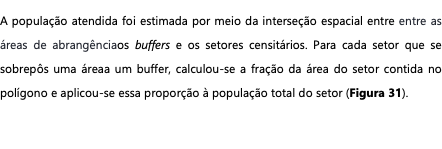
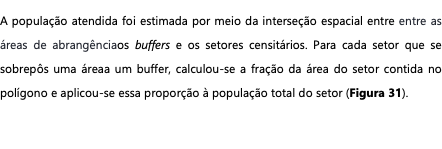
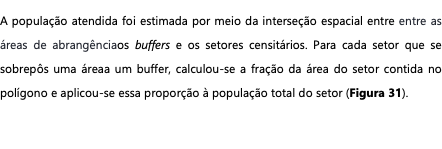
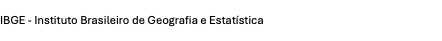
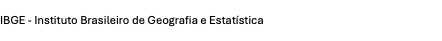
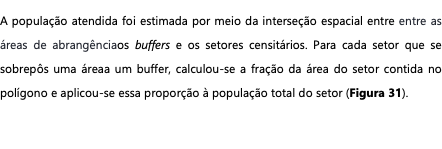
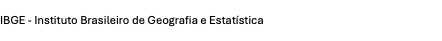
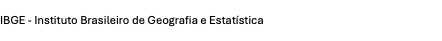

#### Ozônio (O₃)
<div style="text-align: justify">Em 2024, os estados da Região Sudeste concentraram a maior parcela da população atendida pelo monitoramento de ozônio, totalizando 25,7 milhões de habitantes (cerca de 30% da população regional) e 275 estações em operação. No Sul, a cobertura alcançou 7% da população regional, seguida pelo Centro-Oeste (4%), Nordeste (3,2%) e Norte, onde apenas Roraima forneceu dados das estações de monitoramento para esse poluente, correspondendo a 0,3% da população da região.</div>

#### Monóxido de Carbono (CO)
<div style="text-align: justify">Cerca de 20,5 milhões de brasileiros viviam, em 2024, em áreas com monitoramento de CO, dos quais 16 milhões localizados na Região Sudeste (aproximadamente 19% da população regional). A cobertura atingiu ainda 6% da população no Sul, 3,8% no Centro-Oeste, 3,6% no Nordeste e 0,3% no Norte. </div>

#### Dióxido de Nitrogênio (NO₂)
<div style="text-align: justify">Em 2024, a Região Sudeste concentrou cerca de 26% da população coberta pelo monitoramento de NO₂, respondendo por mais de 85% da população atendida no país. Em seguida, o Sul apresentou cobertura de aproximadamente 4,5%, o Centro-Oeste de 3,9%, o Nordeste de 3,3% e o Norte de 0,3%.</div>


#### Dióxido de Enxofre (SO₂)
<div style="text-align: justify">O monitoramento de SO₂, em 2024, abrangeu aproximadamente 17,3% da população da Região Sudeste, que concentrou a maior parte da cobertura nacional para esse poluente. No Sul, a população atendida correspondeu a 6,9%, enquanto no Centro-Oeste e Nordeste os valores foram semelhantes, em torno de 3,6% e 3,3%, respectivamente. No Norte, a cobertura foi reduzida, alcançando apenas 0,3% da população regional, com Roraima sendo o único estado com monitoramento ativo desse poluente.</div>


#### Material Particulado Fino (MP₂,₅)
<div style="text-align: justify">O monitoramento de MP₂,₅ apresentou a maior concentração de estações na Região Sudeste, onde cerca de 25,7 milhões de habitantes, equivalentes a 22,8% da população regional, viviam em áreas com medições desse poluente. Contudo, o maior percentual de cobertura populacional foi observado na Região Norte, onde aproximadamente 29,7% da população estava abrangida pelo monitoramento, realizado majoritariamente por equipamentos indicativos. No Sul, a cobertura alcançou 8% da população, enquanto no Centro-Oeste correspondeu a 7,7% e no Nordeste, 3,5%.</div>

#### Material Particulado Inalável (MP₁₀)
<div style="text-align: justify">O monitoramento de MP₁₀ apresentou maior cobertura populacional na Região Sudeste, onde aproximadamente 26,8% da população vivia em áreas com estações que realizam medições desse poluente. Em seguida, a Região Sul apresentou cobertura de 7,9%, o Centro-Oeste de 6,5% e o Nordeste de 3,0%. Na Região Norte, não houve registro de monitoramento ativo de MP₁₀ nas áreas consideradas.</div>
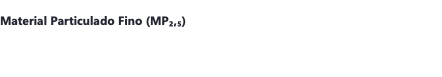
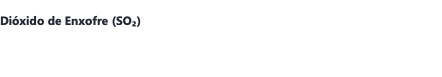
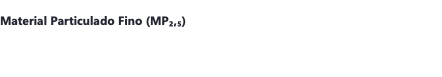
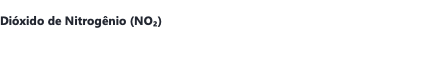
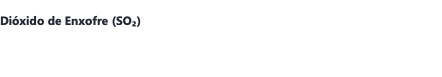
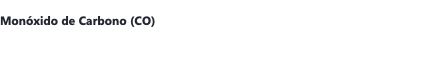
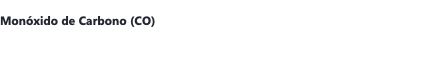
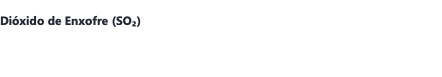
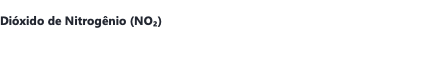
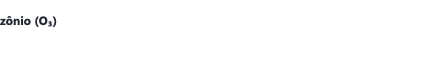
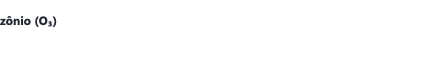
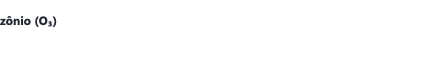
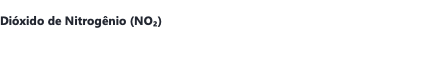
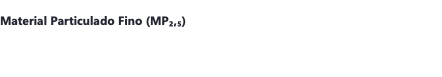
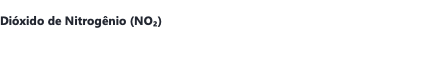
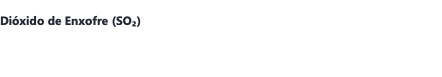
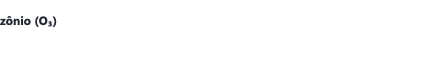
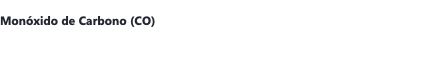
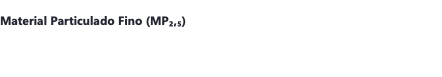
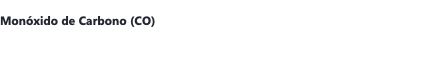

In [5]:
import json
from pathlib import Path
from IPython.display import HTML

# Ajuste o caminho para a pasta onde o script Python gerou os GeoJSONs
GEOJSON_DIR = Path("../_static/representatividade/populacao_geojson")

data = {}
# Carrega os GeoJSONs *separados* por categoria (ex: MP25_Indicativa, MP25_Referencia)
for f in GEOJSON_DIR.glob("*.geojson"):
    if f.stem.endswith(('_Indicativa', '_Referencia')):
        with open(f, encoding="utf-8") as fh:
            # A chave do dicionário será "POLUENTE_CATEGORIA" (ex: MP25_Indicativa)
            data[f.stem] = json.load(fh)

data_json = json.dumps(data, ensure_ascii=False)

# Extrai os nomes dos poluentes únicos para o dropdown
POLUENTES = sorted(list(set([k.split('_')[0] for k in data.keys()])))
pols_json = json.dumps(POLUENTES, ensure_ascii=False)


html_template = r"""
<!DOCTYPE html>
<html lang="pt-br">
<head>
<meta charset="utf-8"/>
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>

<style>
#map { width:100%; height:640px; border:1px solid #ddd; }
.leaflet-control.custom-legend {
  background:#fff;
  padding:8px;
  border-radius:6px;
  box-shadow:0 1px 4px rgba(0,0,0,.4);
  font-size:12px;
}
</style>
</head>

<body>

<div style="margin-bottom:8px;">
  <b>Poluente:</b>
  <select id="selPol"></select>
  <span id="status" style="color:crimson;margin-left:6px;"></span>
</div>

<div style="margin-bottom:8px; display:inline-block; margin-right: 15px;">
  <b>Categoria:</b>
  <input type="checkbox" id="checkInd" value="Indicativa" checked> <label for="checkInd">Indicativa</label>
  <input type="checkbox" id="checkRef" value="Referencia" checked> <label for="checkRef">Referência/Outras</label>
</div>

<div id="map"></div>

<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>

<script>
// =============================
// DADOS
// =============================
var DATA = __DATA__;
var POLUENTES = __POLS__;

// =============================
// FUNÇÕES AUXILIARES
// =============================
function getProp(p, keys) {
  for (var i = 0; i < keys.length; i++) {
    var k = keys[i];
    if (p.hasOwnProperty(k) && p[k] !== null && p[k] !== undefined) {
      return p[k];
    }
  }
  return null;
}

function toNumber(v) {
  if (v === null || v === undefined) return NaN;
  var n = parseFloat(String(v).replace(",", "."));
  return isNaN(n) ? NaN : n;
}

// =============================
// CORES POPULACIONAIS (REFERÊNCIA/OUTRAS - PALETA VERMELHOS)
// =============================
function corPop(v) {
    if (v == null || isNaN(v)) return "#999999"; // Cinza
    if (v < 1000)    return "#fee5d9";
    if (v < 10000)   return "#fcae91";
    if (v < 100000)  return "#fb6a4a";
    if (v < 1000000) return "#de2d26";
    return "#a50f15";
}

// =============================
// CORES POPULACIONAIS INDICATIVAS (NOVA PALETA - VERDES)
// =============================
function corPopIndicativa(v) {
    if (v == null || isNaN(v)) return "#666666"; // Cinza mais escuro
    if (v < 1000)    return "#e0f2f7"; // Azul claro (para contraste)
    if (v < 10000)   return "#bae4b3"; 
    if (v < 100000)  return "#74c476"; 
    if (v < 1000000) return "#31a354"; 
    return "#006d2c"; 
}

// =============================
// POPUP
// =============================
function popupHTML(p, pol) {
  var id  = getProp(p, ["ID_OEMA"]) || "—";
  var id_mma  = getProp(p, ["ID_MMA_COMPLETO"]) || "—";
  var uf  = getProp(p, ["UF"]) || "—";
  var cat_grupo = getProp(p, ["CLASSIFICACAO"]) || "Não Classificado"; 
  var cat_original = getProp(p, ["CATEGORIA"]) || "Não Declarada"; 

  var pop = getProp(p, ["POP_BUFFER", "POPULACAO", "POP"]);
  var popNum = toNumber(pop);
  var popTxt = "—";
  if (!isNaN(popNum)) {
      popTxt = Math.round(popNum).toLocaleString("pt-BR");
  }

  var rep = getProp(p, ["REP_ESPACIAL"]);
  var repTxt = (rep === null ? "—" : String(rep) + " m");

  return (
    '<div style="font-family:Arial;font-size:12px;">' +
    '<b>ID OEMA:</b> ' + id + '<br>' +
    '<b>ID MMA:</b> ' + id_mma + '<br>' +
    '<b>UF:</b> ' + uf + '<br>' +
    '<b>Poluente:</b> ' + pol + '<br>' +
    '<b>Classificação:</b> ' + cat_grupo + '<br>' +
    '<b>Categoria Original:</b> ' + cat_original + '<br>' + 
    '<b>População atendida:</b> ' + popTxt + '<br>' +
    '<b>Raio representativo:</b> ' + repTxt +
    '</div>'
  );
}


// =============================
// MAPA BASE
// =============================
var map = L.map("map", {
  minZoom:3.5,
  maxZoom:13,
  maxBounds: L.latLngBounds([-34,-74],[6,-34]),
  maxBoundsViscosity:0.8
}).setView([-14,-52], 4);

L.tileLayer(
  "https://cartodb-basemaps-a.global.ssl.fastly.net/light_all/{z}/{x}/{y}.png",
  {attribution:"© OpenStreetMap, © CartoDB"}
).addTo(map);

var currentLayers = L.layerGroup(); 
var legend = null;

// =============================
// LEGENDA (DUAS PALETAS)
// =============================
function addLegend(){
  if (legend) map.removeControl(legend);

  legend = L.control({position:"bottomleft"});
  legend.onAdd = function(){
    var div = L.DomUtil.create("div","leaflet-control custom-legend");
    div.innerHTML = "<b>População atendida</b><br>" +
      // Legenda para Referência/Outras (Paleta Vermelha)
      '<i>Estações de Referência/Outras:</i><br>' +
      '<div><span style="background:#fee5d9;width:14px;height:10px;display:inline-block;margin-right:6px;"></span> &lt; 1 mil</div>' +
      '<div><span style="background:#fcae91;width:14px;height:10px;display:inline-block;margin-right:6px;"></span> 1k – 10k</div>' +
      '<div><span style="background:#fb6a4a;width:14px;height:10px;display:inline-block;margin-right:6px;"></span> 10k – 100k</div>' +
      '<div><span style="background:#de2d26;width:14px;height:10px;display:inline-block;margin-right:6px;"></span> 100k – 1M</div>' +
      '<div><span style="background:#a50f15;width:14px;height:10px;display:inline-block;margin-right:6px;"></span> &gt; 1M</div>' +
      '<div><span style="background:#999999;width:14px;height:10px;display:inline-block;margin-right:6px;"></span> Sem dado</div>' +
      '<br>' + // Separador
      // Legenda para Indicativas (Paleta Verde com Borda)
      '<i>Estações Indicativas:</i><br>' +
      '<div><span style="background:#e0f2f7;width:14px;height:10px;display:inline-block;margin-right:6px;border:1px solid #000;"></span> &lt; 1 mil</div>' + 
      '<div><span style="background:#bae4b3;width:14px;height:10px;display:inline-block;margin-right:6px;border:1px solid #000;"></span> 1k – 10k</div>' +
      '<div><span style="background:#74c476;width:14px;height:10px;display:inline-block;margin-right:6px;border:1px solid #000;"></span> 10k – 100k</div>' +
      '<div><span style="background:#31a354;width:14px;height:10px;display:inline-block;margin-right:6px;border:1px solid #000;"></span> 100k – 1M</div>' +
      '<div><span style="background:#006d2c;width:14px;height:10px;display:inline-block;margin-right:6px;border:1px solid #000;"></span> &gt; 1M</div>' +
      '<div><span style="background:#666666;width:14px;height:10px;display:inline-block;margin-right:6px;border:1px solid #000;"></span> Sem dado</div>';
    return div;
  };
  legend.addTo(map);
}

// =============================
// FUNÇÃO PARA CRIAR CAMADA (Layer Factory)
// =============================
function createLayer(geoJsonData, isIndicativa, pol){
    // Define qual função de cor usar (Vermelha ou Verde)
    var getCorPreenchimento = isIndicativa ? corPopIndicativa : corPop;
    
    return L.geoJSON(geoJsonData,{
        style: function(f){
          // Estilo para Polígonos (Cor da respectiva paleta)
          var p = f.properties || {};
          var popVal = getProp(p, ["POP_BUFFER","POPULACAO","POP"]);
          var n = toNumber(popVal);
          var c = getCorPreenchimento(n);
          return { color:c, fillColor:c, weight:0.7, fillOpacity:0.55 };
        },
        pointToLayer: function(f, latlng){
          // Estilo para Pontos
          var p = f.properties || {};
          var popVal = getProp(p, ["POP_BUFFER","POPULACAO","POP"]);
          var n = toNumber(popVal);
          
          var corPreenchimento = getCorPreenchimento(n); 

          // Destaque para Indicativas: Borda Preta
          var corBorda = isIndicativa ? "#000" : corPreenchimento; 
          var espessuraBorda = isIndicativa ? 1.5 : 1; 
          var raio = isIndicativa ? 6 : 5; 
          
          return L.circleMarker(latlng,{
            radius: raio, 
            color: corBorda, 
            fillColor: corPreenchimento,
            fillOpacity:1.0, 
            weight: espessuraBorda 
          });
        },
        onEachFeature: function(f, lyr){
          var p = f.properties || {};
          lyr.bindPopup(popupHTML(p, pol));
        }
    });
}


// =============================
// ATUALIZAR MAPA (COM FILTRO DE CATEGORIA)
// =============================
function updateMap(){
  var sel = document.getElementById("selPol");
  var pol = sel.value;
  var status = document.getElementById("status");
  
  // Leitura dos filtros de categoria
  var checkInd = document.getElementById("checkInd").checked;
  var checkRef = document.getElementById("checkRef").checked;

  currentLayers.clearLayers();
  status.textContent = "";

  var bounds = [];
  var dataFound = false;

  // 1. Tenta carregar e adicionar a camada Indicativa
  if (checkInd) {
    var gj_ind = DATA[pol + "_Indicativa"];
    if (gj_ind) {
      var layerInd = createLayer(gj_ind, true, pol); // true = usa paleta verde
      currentLayers.addLayer(layerInd);
      var b = layerInd.getBounds();
      if (b.isValid()) bounds.push(b);
      dataFound = true;
    }
  }

  // 2. Tenta carregar e adicionar a camada de Referência
  if (checkRef) {
    var gj_ref = DATA[pol + "_Referencia"];
    if (gj_ref) {
      var layerRef = createLayer(gj_ref, false, pol); // false = usa paleta vermelha
      currentLayers.addLayer(layerRef);
      var b = layerRef.getBounds();
      if (b.isValid()) bounds.push(b);
      dataFound = true;
    }
  }
  
  if (!dataFound) {
    status.textContent = "Sem dados para o Poluente/Categoria(s) selecionado(s) (" + pol + ")";
    if (legend) map.removeControl(legend);
    return;
  }
  
  currentLayers.addTo(map);

  addLegend();

  // Ajusta o zoom para as camadas combinadas
  if (bounds.length > 0) {
    var allBounds = bounds[0];
    for (var i = 1; i < bounds.length; i++) {
        allBounds.extend(bounds[i]);
    }
    if (allBounds.isValid()) map.fitBounds(allBounds, {padding:[20,20]});
  }
}

// =============================
// DROPDOWN E LISTENERS
// =============================
var sel = document.getElementById("selPol");
for (var i=0; i<POLUENTES.length; i++) {
  var opt = document.createElement("option");
  opt.value = POLUENTES[i];
  opt.textContent = POLUENTES[i];
  sel.appendChild(opt);
}
if (POLUENTES.indexOf("MP25") >= 0) {
  sel.value = "MP25";
} else {
  sel.value = POLUENTES[0];
}
sel.addEventListener("change", updateMap);
document.getElementById("checkInd").addEventListener("change", updateMap);
document.getElementById("checkRef").addEventListener("change", updateMap);

updateMap();
</script>
</body>
</html>
"""

html_code = (
    html_template
      .replace("__DATA__", data_json)
      .replace("__POLS__", pols_json)
)

# Renderiza o código HTML no Jupyter
HTML(html_code)

<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Fig. 31</em> Representação espacial e numérica da população atendida pelo monitoramento da qualidade do ar de referência (ou equivalente) e indicativo. Análise realizada utilizando dados do IBGE (2019, 2022a, 2022b)

</p>


Loading ITables v2.5.1 from the init_notebook_mode cell... (need help?)

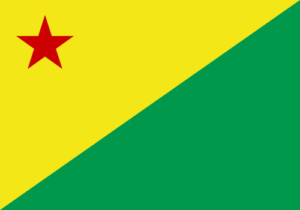
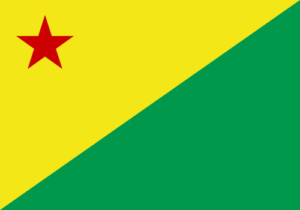
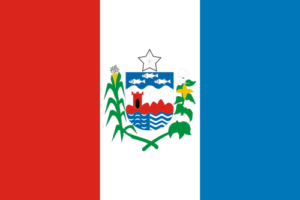
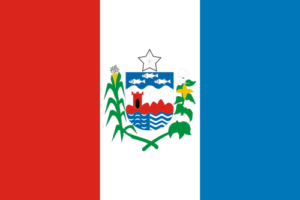
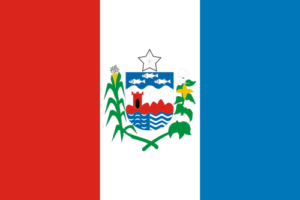
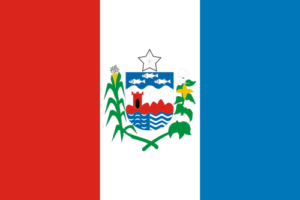
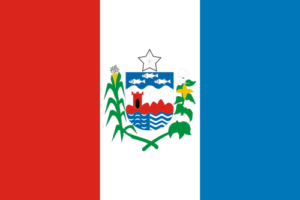
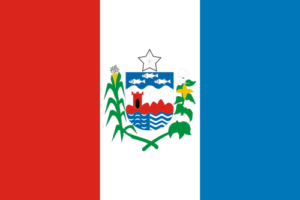
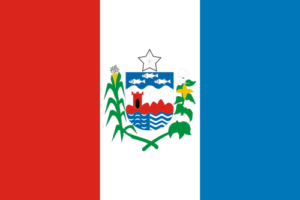
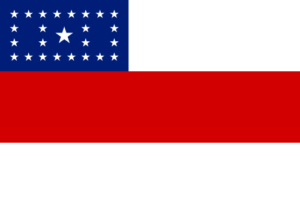
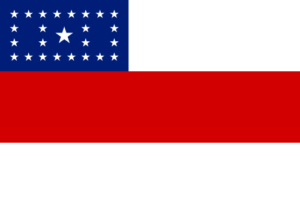
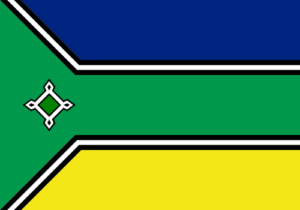
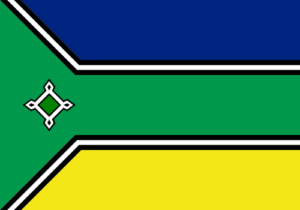
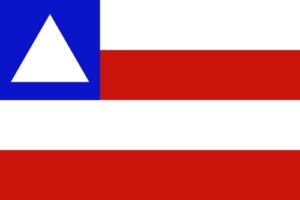
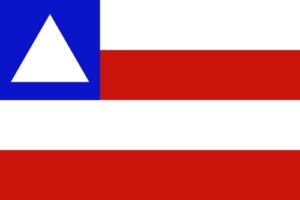
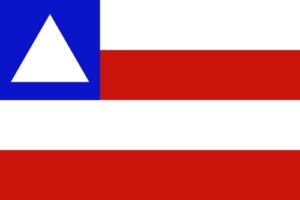
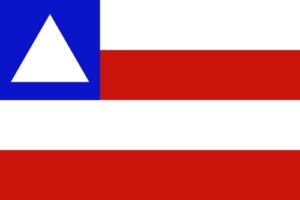
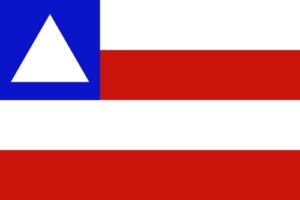
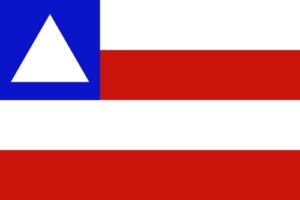
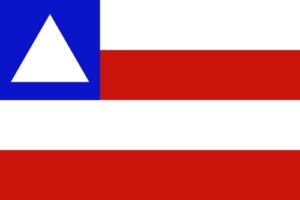
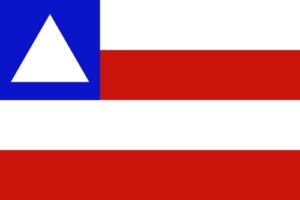
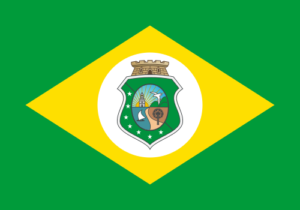
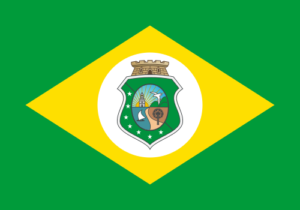
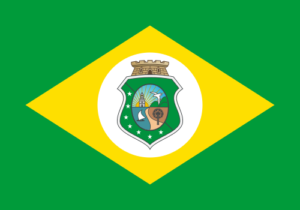
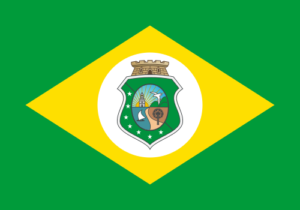
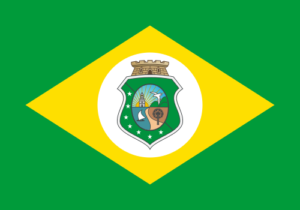
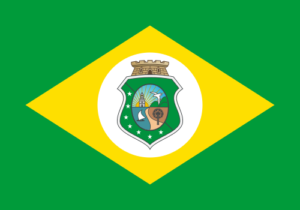
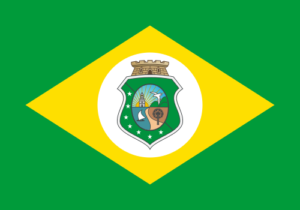
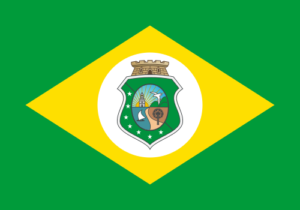
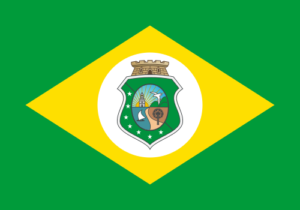
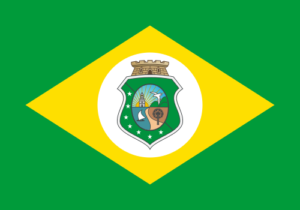
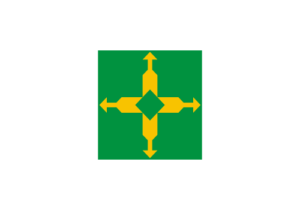
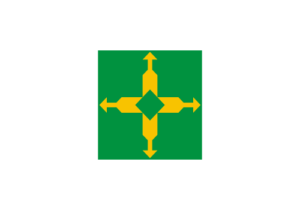
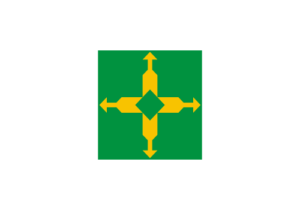
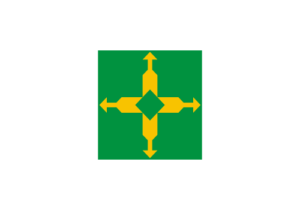
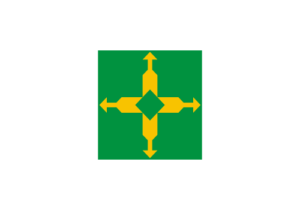
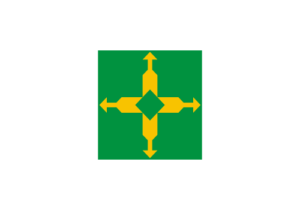
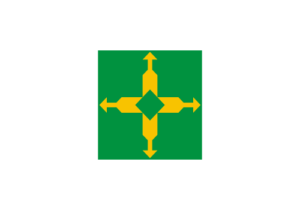
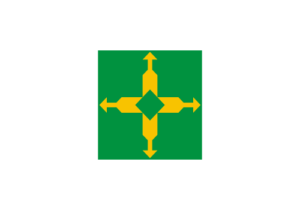
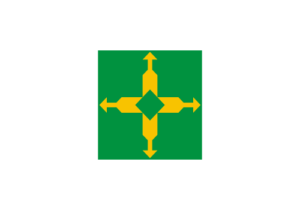
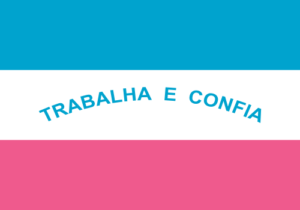
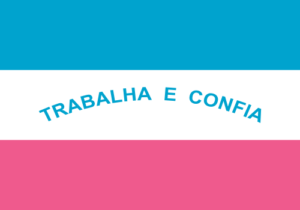
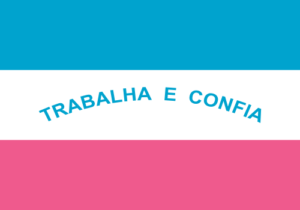
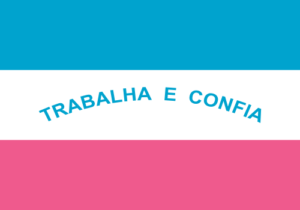
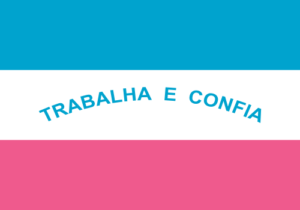
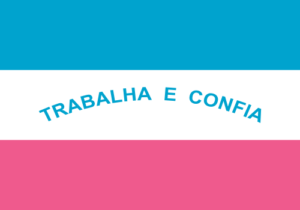
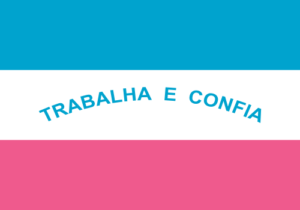
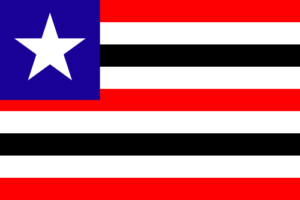
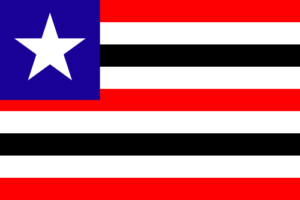
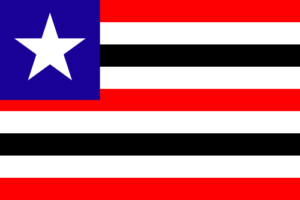
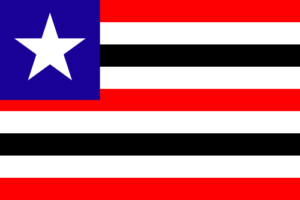
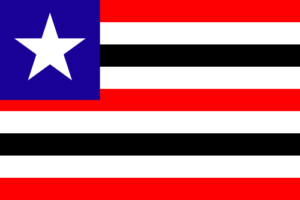
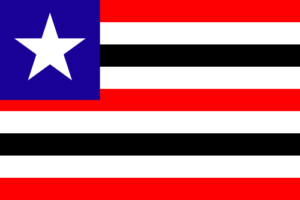
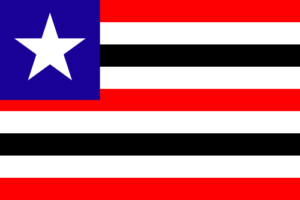
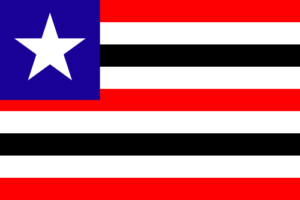
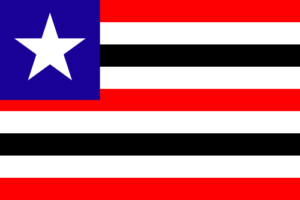
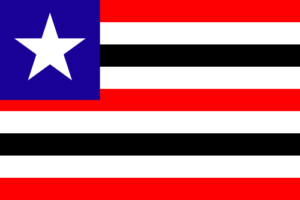
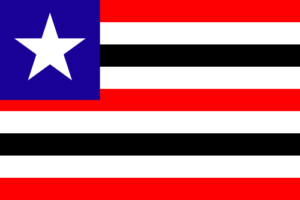
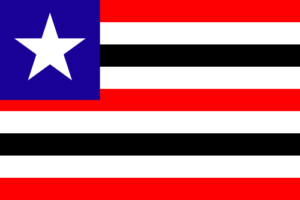
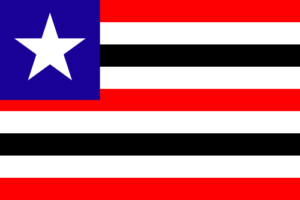
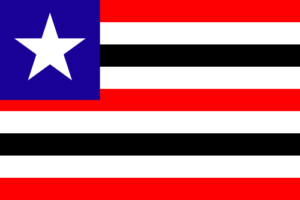
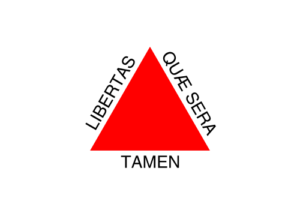
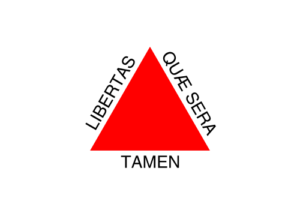
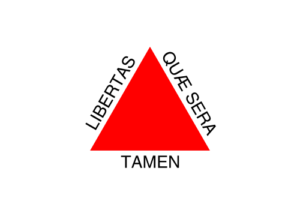
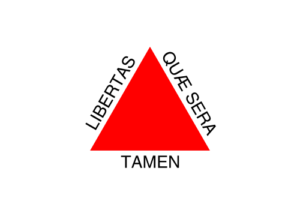
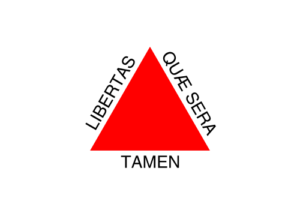
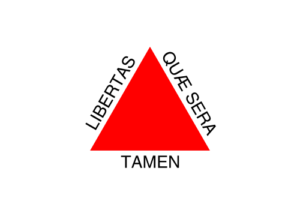
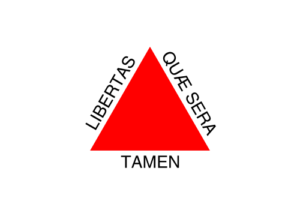
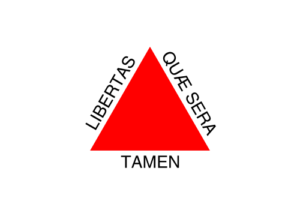
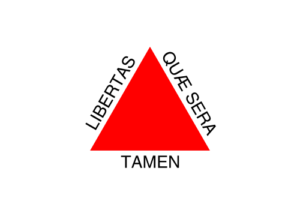
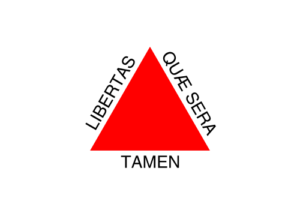
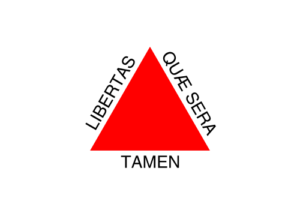
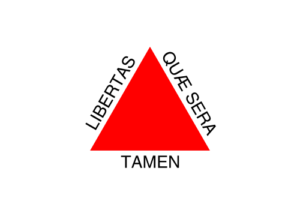
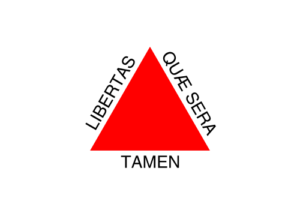
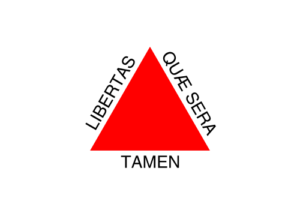
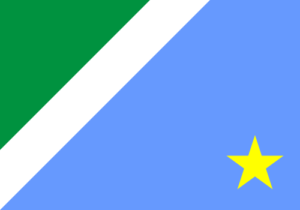
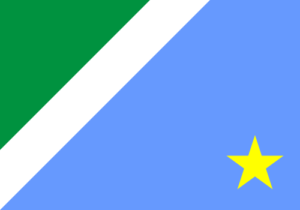
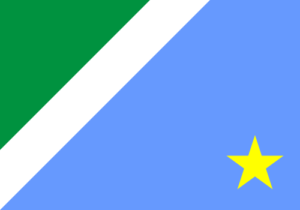
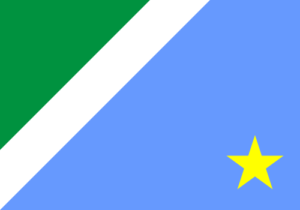
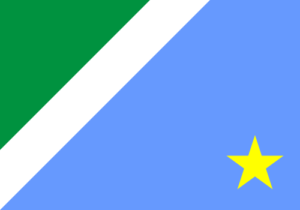
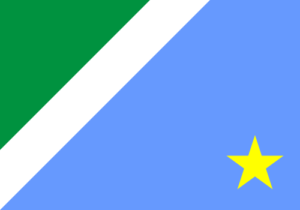
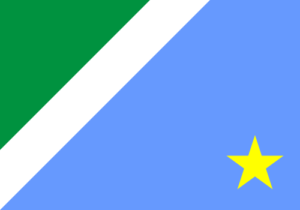
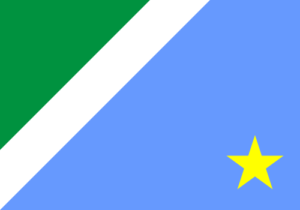
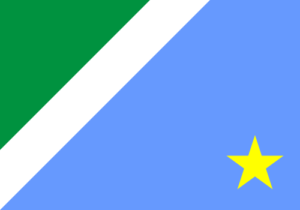
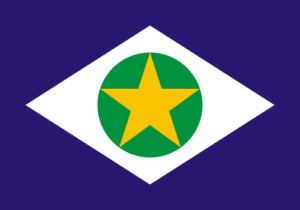
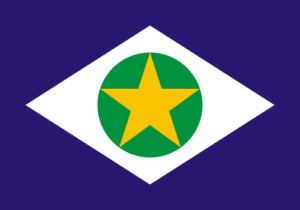
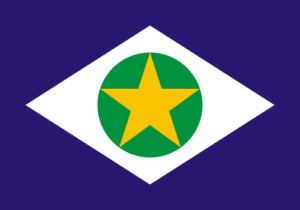
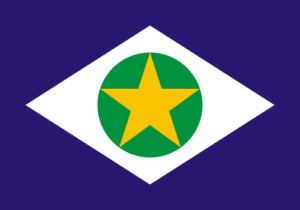
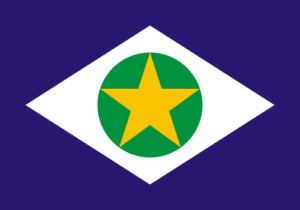
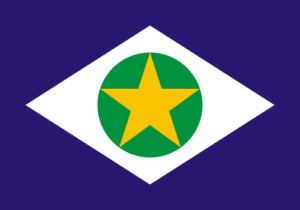
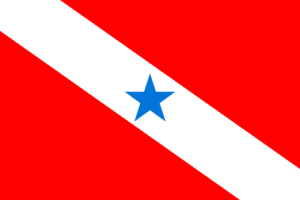
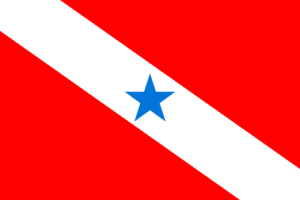
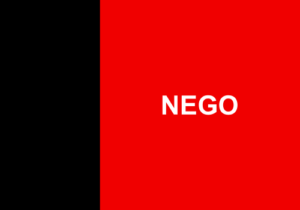
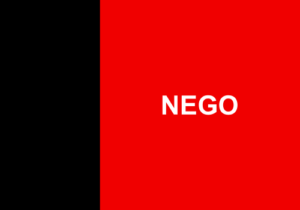
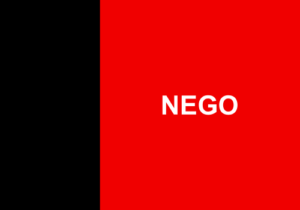
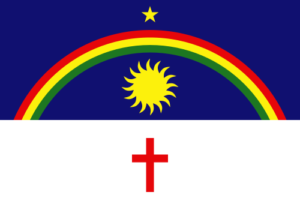
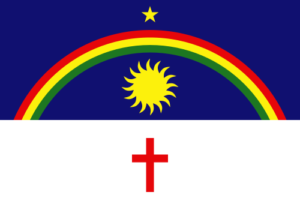
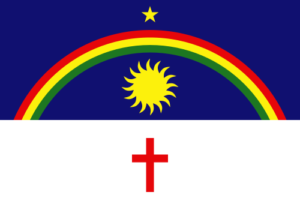
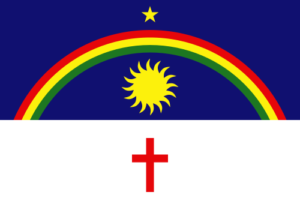
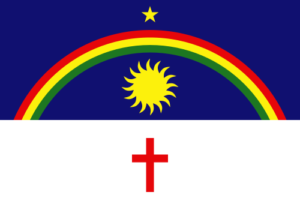
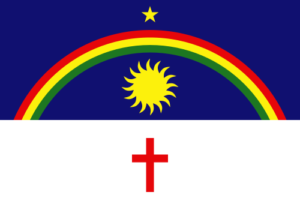
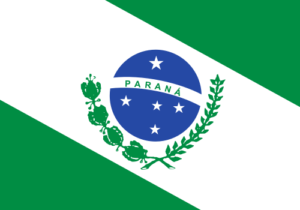
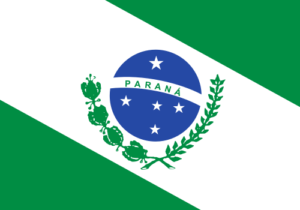
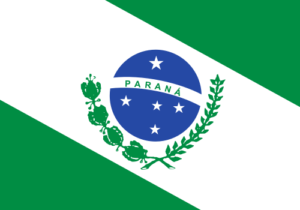
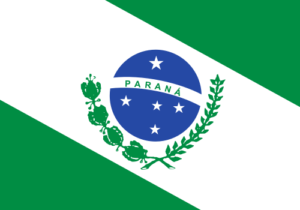
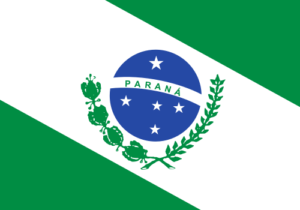
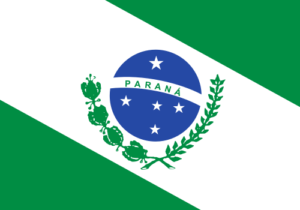
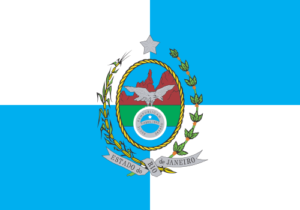
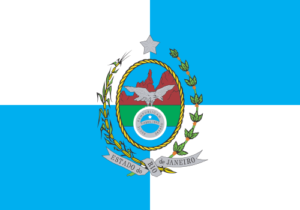
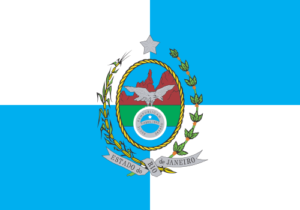
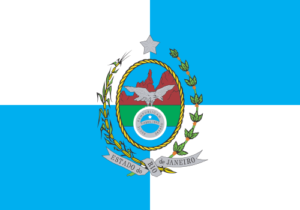
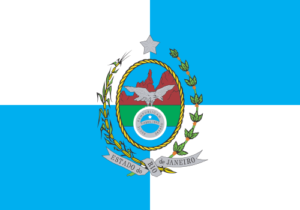
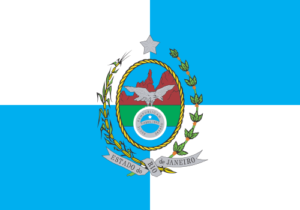
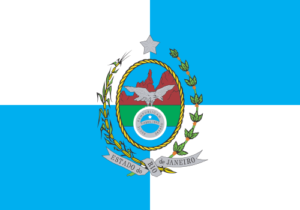
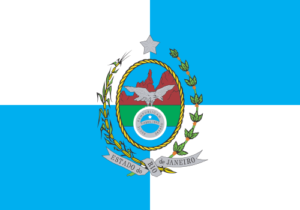
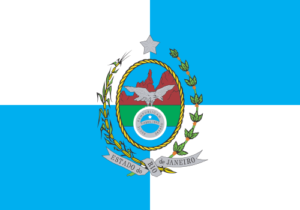
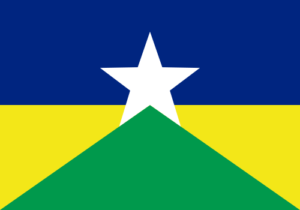
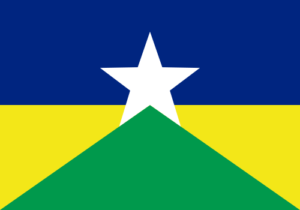
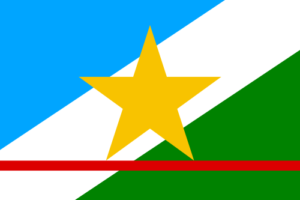
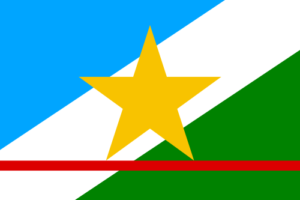
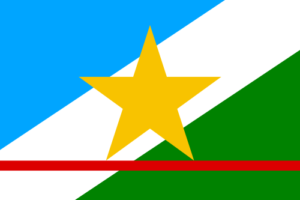
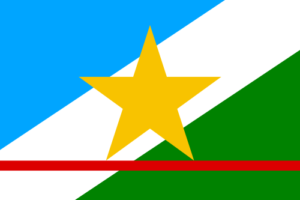
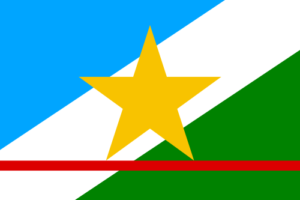
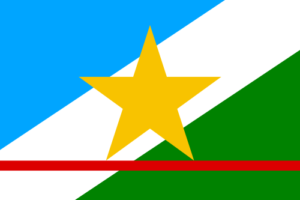
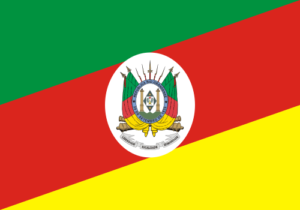
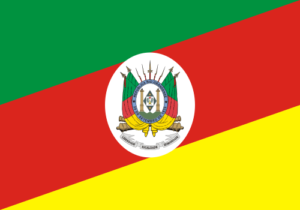
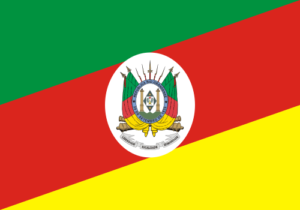
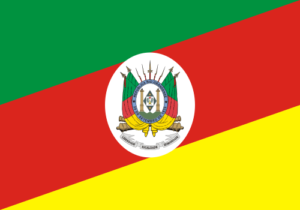
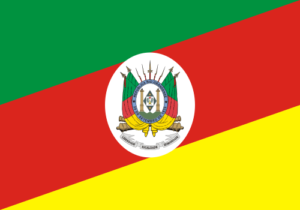
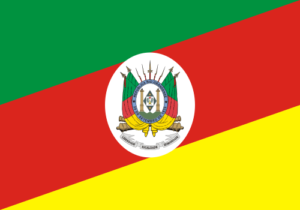
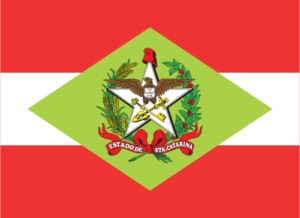
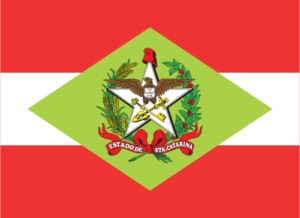
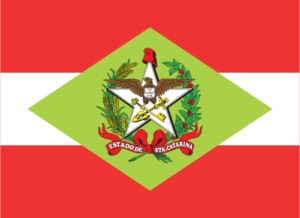
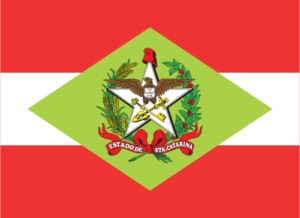
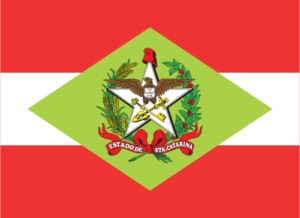
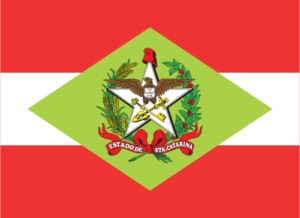
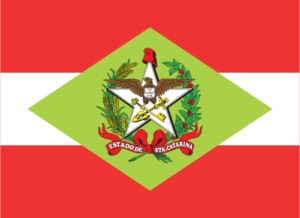
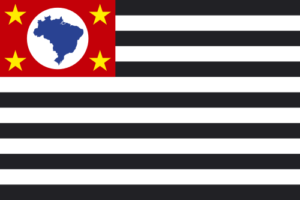
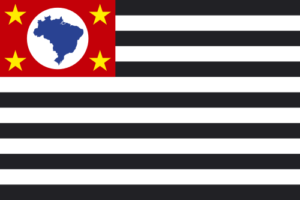
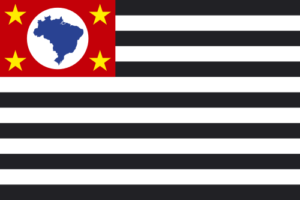
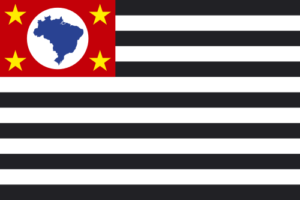
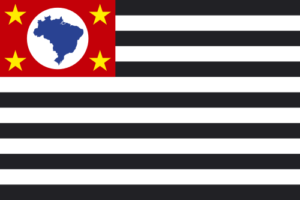
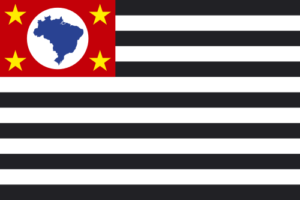
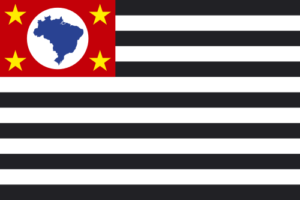
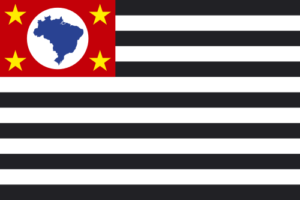
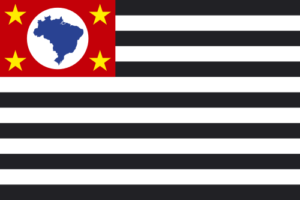
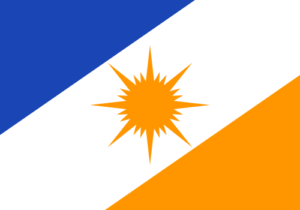
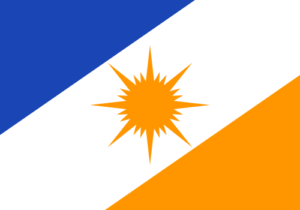

In [1]:
import pandas as pd
import warnings
import importlib

# Seus módulos
import scripts.flagTables as flagtab
import scripts.stationsPopTableGeo as popGeo

importlib.reload(flagtab)
importlib.reload(popGeo)
warnings.filterwarnings('ignore')

# 1. Carregar a tabela PRONTA (lê do CSV gerado anteriormente)
df_pop = popGeo.carregar_tabela_pronta()

# 2. Limpeza de segurança (caso o CSV tenha sujeira)
uf_series = df_pop['UF'].astype(str).str.strip()
mask_invalid_uf = (
    uf_series.eq('') |
    uf_series.str.lower().isin(['não declarado', 'nao declarado', 'nan']) |
    df_pop['UF'].isna()
)
df_pop = df_pop[~mask_invalid_uf].reset_index(drop=True)

# 3. Definir Filtros do SearchPane
# Índices: [0: Bandeira, 1: UF, 2: Poluente, 3: Categoria, 4: População, 5: Estações]
searchPaneColumns = [1, 2, 3]

# 4. Exibir tabela interativa
flagtab.tabela_iterativa(df_pop, searchPaneColumns)

<p style="text-align:center; color:#636D7D; font-size:15.5px;">
  <em>Tabela 19 -</em>  Estimativa da população atendida pelo monitoramento da qualidade do ar de referência (ou equivalente) e indicativo em cada UF. Análise realizada utilizando dados do IBGE (2019, 2022a, 2022b)
</p><br/>

### Referências

<!-- BIBLIOGRAPHY START -->
<div class="csl-bib-body">
  <div class="csl-entry"><i id="zotero|22267313/8BP8CELT"></i>IBGE. <b>Bases de dados e tabelas: Áreas Urbanizadas 2019 – Brasil (shapefile)</b>. , 2019. </div>
  <div class="csl-entry"><i id="zotero|22267313/43V9SKCC"></i>IBGE. <b>Censo Demográfico 2022</b>. , 2022a. </div>
  <div class="csl-entry"><i id="zotero|22267313/4YP56BJF"></i>IBGE. <b>Malhas territoriais</b>. , 2022b. </div>
</div>
<!-- BIBLIOGRAPHY END -->